In [1]:
import numpy as np 
import pickle 
from scipy.stats import spearmanr
from tqdm.auto import tqdm
import pandas as pd
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# model_name = 'attn_cue_jsin_multi_distractor_w_audioset_full_SNR_-20_to_20_bs_64_lr_1e-4'
model_name = 'attn_cue_match_target_speech_distractor_only'
out_name = f'../attn_cue_models/{model_name}/model_output_reps_0dB.npz'

activations = np.load(out_name, allow_pickle=True)


In [3]:
mixture_reps = activations['mixture_reps'].item()
fg_reps = activations['fg_reps'].item()
bg_reps = activations['bg_reps'].item()


In [ ]:
from multiprocessing import Pool, get_context


In [4]:
## Get correlations by layer

fg_corr_results = {}
bg_corr_results = {}


n_sounds = 100

for layer, mixture_acts in tqdm(mixture_reps.items()):
    fg_acts  = fg_reps[layer]
    bg_acts = bg_reps[layer]
    
    # Calculate corr coefs for mixture and foreground
    fg_r = np.corrcoef(mixture_acts, fg_acts)
#     fg_r = spearmanr(mixture_acts, fg_acts, axis=1)[0]

    # get coeffs of wanted samples
    fg_corr_results[layer] = np.diagonal(fg_r[:100, 100:])
    
    # Calculate corr coefs for mixture and background
    bg_r = np.corrcoef(mixture_acts, bg_acts)
#     bg_r = spearmanr(mixture_acts, bg_acts, axis=1)[0]

    # get coeffs of background 
    bg_corr_results[layer] = np.diagonal(bg_r[:100, 100:])
    
    

 78%|███████▊  | 7/9 [04:53<00:31, 15.98s/it] /om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/numpy/lib/function_base.py:2829: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/numpy/lib/function_base.py:2830: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]
100%|██████████| 9/9 [05:00<00:00, 33.35s/it]


In [5]:
out_name = f'../{model_name}_corrs_at_0dB.pkl'

out_dict = dict(fg_corr_results=fg_corr_results, bg_corr_results=bg_corr_results)

with open(out_name ,'wb') as f:
    pickle.dump(out_dict, f) 

In [6]:
# put into df for easy plotting:

dfs = []
for layer in fg_corr_results.keys():
    df = pd.DataFrame.from_dict({'fg_corrs':fg_corr_results[layer],
                                 'bg_corrs':bg_corr_results[layer],
                                 'layer': [layer] * len(fg_corr_results[layer])})
            
    dfs.append(df)
corr_results = pd.concat(dfs)


In [7]:

results = pd.melt(corr_results, id_vars =['layer'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                            value_name="Pearson's r")

In [10]:

results['Stream'].replace('fg_corrs','target',inplace=True)
results['Stream'].replace('bg_corrs','distractor',inplace=True)


In [11]:
layer_order = sorted(results.layer.unique())

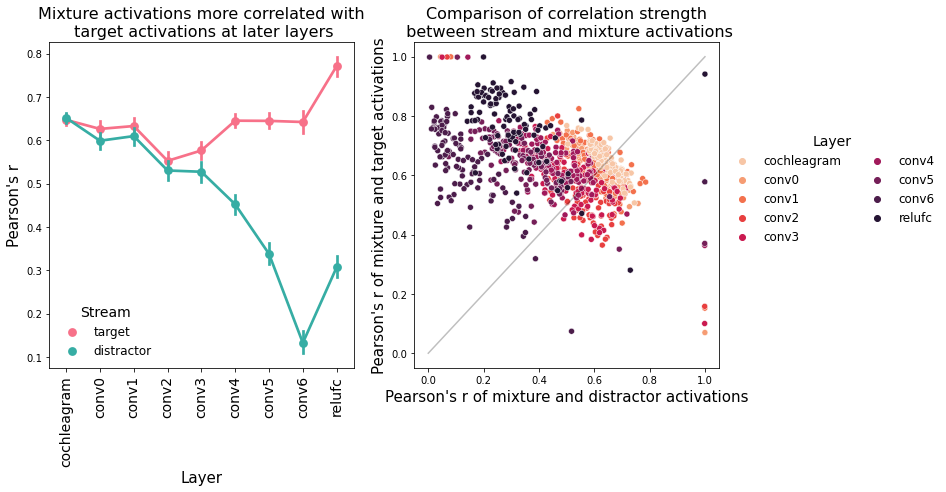

In [12]:
fig, axs = plt.subplots(1,2, figsize=(12,6))


x = y = np.linspace(0,1,100)

sns.pointplot(data=results, x='layer', y="Pearson's r",
              hue = 'Stream', palette='husl', ax=axs[0],
              order = layer_order,
              ci=95, n_boot=10000, seed=1)


axs[1].plot(x,y,'k-', alpha=0.25)
sns.scatterplot(data=corr_results, x='bg_corrs', y='fg_corrs',
                hue='layer',hue_order=layer_order, palette='rocket_r', ax=axs[1])



axs[1].set_title("Comparison of correlation strength\n between stream and mixture activations", fontsize=16)
axs[1].set_xlabel("Pearson's r of mixture and distractor activations", fontsize=15)
axs[1].set_ylabel("Pearson's r of mixture and target activations", fontsize=15)
axs[1].legend(title='Layer', ncol=2, frameon=False,
              bbox_to_anchor=(1, 0.75), fontsize=12, title_fontsize=14)

axs[0].set_title("Mixture activations more correlated with\n target activations at later layers", fontsize=16)
axs[0].set_xticklabels(layer_order, rotation=90, fontsize=14);
axs[0].set_ylabel("Pearson's r", fontsize=15)
axs[0].set_xlabel("Layer", fontsize=15)
axs[0].legend(title='Stream', loc='lower left', frameon=False,
              fontsize=12, title_fontsize=14)


# plt.tight_layout()